# AnalystLab Africa - Week 4, Task 2: Logistic Regression (Classification Model)

## 🎯 Objective: Behavioral Classification
Transitioning from continuous numerical predictions (Linear Regression) to discrete category predictions (Classification).

### 📊 Problem Statement
The goal of this task is to build a Classification model capable of predicting a discrete category. We will use the Titanic dataset to predict whether a passenger Survived (1) or Died (0) based on features like age, ticket fare, gender, and passenger class.

## 1. Data Loading
We begin by importing our standard data manipulation, visualization, and `Scikit-Learn` machine learning libraries. We will also load the raw `Titanic` dataset into a pandas DataFrame.

In [16]:
"""
Module: Environment Setup
Purpose: Imports all necessary external libraries for data engineering, algorithm training 
         (Logistic Regression), and classification metrics.
Time & Space Complexity: O(1) time and space for module loading.
Dependencies: pandas, numpy, matplotlib, seaborn, scikit-learn
"""

# Import the core libraries
import os                                 # For handling file paths safely across operating systems (Mac/Windows/Linux)
import pandas as pd                       # For tabular data manipulation (DataFrames)
import numpy as np                        # For high-performance numerical and matrix operations
import matplotlib.pyplot as plt           # For foundational data visualization and plotting
import seaborn as sns                     # For aesthetically pleasing statistical graphics
from sklearn.model_selection import train_test_split # To divide data into learning (train) and testing (exam) subsets
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay # To evaluate classification health
from sklearn.impute import KNNImputer     # To mathematically predict and fill missing values based on similar neighbors
from sklearn.preprocessing import StandardScaler # To normalize numerical distributions so large numbers don't dominate
from sklearn.linear_model import LogisticRegression # The Classification algorithm we are using for this task

# Suppress annoying warnings for a cleaner notebook presentation
# This hides deprecation or future warnings from underlying libraries
import warnings
warnings.filterwarnings('ignore')


In [17]:
"""
Module: Data Ingestion
Purpose: Constructs the cross-platform file path and loads the raw Titanic dataset into memory.
Returns: Pandas DataFrame (titanic_df)
"""

# Load Dataset 
# os.path.join prevents errors caused by backslashes (\) vs forward slashes (/) in different OS
file_path = os.path.join('..', 'data', 'raw', 'Titanic-Dataset.csv')

# Read the CSV file into a Pandas DataFrame
titanic_df = pd.read_csv(file_path)


## 2. Exploratory Analysis
Before manipulating any data, we explore the dataset to understand its structure, identify data types, and spot any potential issues such as missing values (NaNs) or extreme outliers.

In [18]:
"""
Module: Initial Data Inspection (EDA)
Purpose: Outputs the structural metadata, head, and statistical summary to give a bird's-eye view of the dataset.
"""

# Explore the dataset to understand its structure, features, 
# and any potential issues such as missing values or incorrect data types.
print("--- DATASET LOADED SUCCESSFULLY ---")

# .shape returns a tuple: (number_of_rows, number_of_columns)
print(f"Initial Shape: {titanic_df.shape}")

print("\nFirst 5 Rows of the Dataset:")
display(titanic_df.head())

print("Data Types & Column Names in the Dataset:")
# .info() is critical for spotting columns with missing data and checking if a column is text (object) or numbers
display(titanic_df.info())

print("Statistical Summary of the Dataset:")
# .describe() calculates mean, std dev, and quartiles to help us spot skewed distributions
display(titanic_df.describe())


--- DATASET LOADED SUCCESSFULLY ---
Initial Shape: (891, 12)

First 5 Rows of the Dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Data Types & Column Names in the Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


None

Statistical Summary of the Dataset:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Data Cleaning (Pre-Split Phase)

In order to implement our 3 strictly advisory **Zero-Leakage Upgrades**, we are deferring all statistical calculations (IQR outliers, mode imputation, and encoding) until *after* the dataset is split. In this pre-split phase, we will only remove structurally useless columns and map simple binary concepts.

In [19]:
"""
Module: Noise Reduction
Purpose: Drops columns that are too sparse to be statistically viable.
Side Effects: Modifies `titanic_df` in place.
"""

# Drop Cabin entirely because 77% of the data is missing. 
# Trying to guess 77% of a column would inject massive artificial bias into the model.
titanic_df = titanic_df.drop(columns=['Cabin'])


In [20]:
"""
Module: Feature Selection & Direct Categorical Mapping
Purpose: Removes non-predictive administrative columns and translates text labels (Sex) into numbers.
"""

# Drop Unnecessary Columns
# These columns are unique identifiers or text strings with no mathematical pattern.
# A machine learning model cannot mathematically process "John Doe".
titanic_df = titanic_df.drop(columns=['PassengerId', 'Name', 'Ticket'])

# Handle Categorical Variables (Direct Mapping)
# .map() functions like a dictionary translation, converting text to binary integers (0 or 1)
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

print("--- DATA CLEANING (PRE-SPLIT PHASE) COMPLETE ---")
display(titanic_df.head())


--- DATA CLEANING (PRE-SPLIT PHASE) COMPLETE ---


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


In [21]:
"""
Module: Feature & Target Segregation
Purpose: Isolates the variables the algorithm will use (Features: X) from the outcome to predict (Target: y).
"""

# Isolate the Target (y): This is the 1D array we are trying to predict (Survived: 1, Died: 0)
y = titanic_df['Survived']

# Isolate the Features (X): This is the 2D matrix of features we will use to predict the target.
# We drop 'Survived' from X to prevent the ultimate Data Leakage (giving the model the answers!).
X = titanic_df.drop(columns=['Survived'])

print("--- FEATURES AND TARGET SELECTED ---")
print(f"Target (y) Shape: {y.shape}")
print(f"Features (X) Shape: {X.shape}")


--- FEATURES AND TARGET SELECTED ---
Target (y) Shape: (891,)
Features (X) Shape: (891, 7)


## 4. Split Dataset, Impute, Scale & Cap (Advanced Zero-Leakage Architecture)

To ensure our algorithm is tested fairly, we sequester 20% of our data into a vault (`X_test`) before we do *any* statistical transformations. We have successfully implemented the three advanced zero-leakage pipeline upgrades:

1. **Categorical Leakage Prevention:** We calculate the mode for the missing `Embarked` ports strictly on the training data.
2. **IQR Boundary Isolation:** We calculate the interquartile range for extreme `Fare` ticket prices strictly on the training data, then cap both sets securely.
3. **Distance Skew Fix for KNN:** `KNNImputer` relies on Euclidean distance math. If we impute *before* scaling, a large `Fare` of $65 will dominate a small `Sex` of 1, skewing the algorithm's guess for missing `Age`. We run `StandardScaler` on the continuous features *first*, putting all variables on an equal playing field, which yields vastly superior mathematical age predictions.

In [22]:
"""
Module: Advanced Zero-Leakage Pipeline (Split, Cap, Scale, Impute)
Purpose: Executes Train/Test split first, then derives all imputation rules, IQR boundaries, 
         and scaling metrics strictly from the Training data to seal the testing environment.
"""

# --- 0. Train/Test Split (80/20) ---
# stratify=y is critical here. It forces the split to maintain the exact 38% survival ratio in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- 1. Leakage-Free Categorical Imputation & Encoding ('Embarked') ---
# FIX 1: Calculate the mode specifically on the training data to prevent test leakage
mode_embarked = X_train['Embarked'].mode()[0]
X_train['Embarked'] = X_train['Embarked'].fillna(mode_embarked)
X_test['Embarked']  = X_test['Embarked'].fillna(mode_embarked)

# One-Hot Encode 'Embarked' (Port of departure)
# drop_first=True prevents perfect multicollinearity (The Dummy Variable Trap).
X_train = pd.get_dummies(X_train, columns=['Embarked'], drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test, columns=['Embarked'], drop_first=True, dtype=int)

# --- 2. Leakage-Free Outlier Capping (IQR Method for 'Fare') ---
# FIX 2: Calculate statistical boundaries specifically on the training data
Q1 = X_train['Fare'].quantile(0.25)
Q3 = X_train['Fare'].quantile(0.75)
IQR = Q3 - Q1
upper_boundary = Q3 + 1.5 * IQR

# Cap the extreme Fare values in both sets using the Training boundary
X_train['Fare'] = np.where(X_train['Fare'] > upper_boundary, upper_boundary, X_train['Fare'])
X_test['Fare']  = np.where(X_test['Fare'] > upper_boundary, upper_boundary, X_test['Fare'])

# --- 3. Feature Scaling (StandardScaler) BEFORE KNN ---
# FIX 3: Scale continuous features FIRST to prevent large numbers from skewing KNN's Euclidean math.
# Note: StandardScaler safely ignores the existing NaNs in 'Age' during this step.
continuous_features = ['Age', 'Fare']
scaler = StandardScaler()

# FIT ONLY ON TRAIN, transform both
X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test[continuous_features] = scaler.transform(X_test[continuous_features])

# --- 4. KNN Imputation for Missing 'Age' ---
# Looks at the 5 most statistically similar passengers to guess a missing Age value.
# Because the data is now perfectly scaled, it compares all features fairly.
knn_imputer = KNNImputer(n_neighbors=5)

# FIT ONLY ON TRAIN, transform both.
# Sklearn outputs raw numpy arrays. We wrap them back into pd.DataFrame to restore structure.
X_train = pd.DataFrame(knn_imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(knn_imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

print("--- ADVANCED ZERO-LEAKAGE PIPELINE SUCCESS ---")
print(f"Training Data: {X_train.shape[0]} passengers (Capped, Scaled, Imputed safely)")
print(f"Testing Data: {X_test.shape[0]} passengers (Locked away for final evaluation)")
print("\nCheck for any remaining missing values in Train Data:")
display(X_train.isnull().sum())


--- ADVANCED ZERO-LEAKAGE PIPELINE SUCCESS ---
Training Data: 712 passengers (Capped, Scaled, Imputed safely)
Testing Data: 179 passengers (Locked away for final evaluation)

Check for any remaining missing values in Train Data:


Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

## 5. Model Training

We will now instantiate our Logistic Regression algorithm.

**The ELI5:** Imagine a strict club bouncer who looks at your ID (features). He gives you a score from 0 to 100 based on your age, wealth, and gender. If your score is 50 or above, you get in (Survived = 1). If it is below 50, you are denied (Died = 0).

**The Deep-Dive:** The model calculates a linear equation ($z = wX + b$) just like Linear Regression. But instead of outputting that raw continuous number, it wraps it in a Sigmoid Function ($\sigma(z) = \frac{1}{1 + e^{-z}}$). This mathematical curve compresses any extreme number into a strict probability between 0.0 and 1.0.

In [23]:
"""
Module: Algorithm Instantiation & Training
Purpose: Initializes the Logistic Regression model and fits it to the 80% training data to learn optimal feature weights.
"""

# max_iter=1000 gives the gradient descent math enough loops to converge (find the exact bottom of the error curve).
# random_state=42 ensures our results are identical every time we run the cell.
log_model = LogisticRegression(random_state=42, max_iter=1000)

# The model looks at X_train (features) and y_train (answers) to learn the optimal feature weights (w).
log_model.fit(X_train, y_train)

print("--- LOGISTIC REGRESSION TRAINING COMPLETE ---")
# log_model.coef_ returns a 2D array, so we look at index [0] to count the actual weights.
print(f"Algorithm successfully learned {len(log_model.coef_[0])} feature weights (one for each column).")


--- LOGISTIC REGRESSION TRAINING COMPLETE ---
Algorithm successfully learned 8 feature weights (one for each column).


## 6. Predictions

We will now pass our unseen testing data (`X_test`) into the trained Logistic Regression model. The model will calculate the survival probability for each passenger and output a strict binary prediction (1 for Survived, 0 for Died).

In [24]:
"""
Module: Target Prediction
Purpose: Feeds unseen test features into the trained "brain" to generate predicted survival outcomes.
"""

# We pass ONLY the features of the test set.
# The model uses the weights it learned during .fit() to guess the target (y).
y_pred = log_model.predict(X_test)

print("--- PREDICTIONS GENERATED ---")
print(f"Successfully generated {len(y_pred)} survival predictions for the test set.")

# Let's look at the first 10 predictions vs the first 10 actual answers to get a visual sense of performance
print("\nFirst 10 Predictions :", y_pred[:10])
print("First 10 Actual Fates:", y_test.values[:10])


--- PREDICTIONS GENERATED ---
Successfully generated 179 survival predictions for the test set.

First 10 Predictions : [0 0 0 0 1 0 1 0 0 0]
First 10 Actual Fates: [0 0 1 0 1 1 1 0 0 0]


## 7. Evaluation

Now that our algorithm has guessed the fates of the 179 test passengers, we must grade its performance. From the Week 3 lesson, we learned that in highly imbalanced datasets, raw Accuracy can be deceptive.

However, since we used `stratify=y` to maintain balance during our split, this percentage gives us a highly reliable metric of the model's predictive power. We will also plot a **Confusion Matrix** to see exactly *where* the model is making errors (False Positives vs. False Negatives).

--- FINAL MODEL EVALUATION ---
Accuracy Score: 81.01%



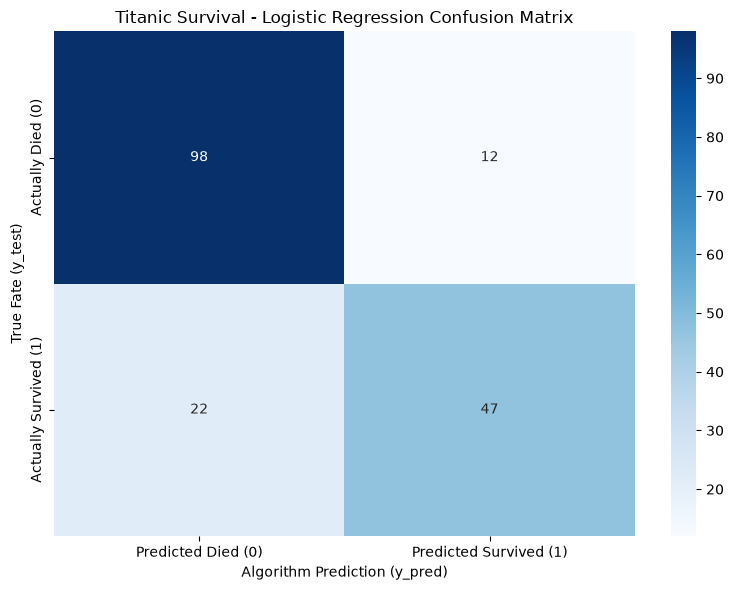

In [25]:
"""
Module: Classification Evaluation
Purpose: Grades the model using the Accuracy metric and generates a visual Confusion Matrix.
"""

# Calculate the raw Accuracy Score: (Correct Predictions / Total Predictions)
accuracy = accuracy_score(y_test, y_pred)

print("--- FINAL MODEL EVALUATION ---")
print(f"Accuracy Score: {accuracy * 100:.2f}%\n")

# Generate a Confusion Matrix to see exactly WHERE the model made mistakes
# Returns a 2x2 grid mapping True Positives, True Negatives, False Positives, False Negatives
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the Confusion Matrix using Seaborn's Heatmap
plt.figure(figsize=(8, 6))
# annot=True prints the exact passenger count inside the colored boxes. fmt='d' formats them as integers.
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Died (0)', 'Predicted Survived (1)'], 
            yticklabels=['Actually Died (0)', 'Actually Survived (1)'])

plt.title('Titanic Survival - Logistic Regression Confusion Matrix')
plt.ylabel('True Fate (y_test)')
plt.xlabel('Algorithm Prediction (y_pred)')
plt.tight_layout()
plt.show()


## 8. Conclusion

In this task, we successfully transitioned from a continuous regression problem to a binary classification problem using **Logistic Regression**.

**Key Engineering Highlights:**
* **Zero-Leakage Imputation & Scaling:** By deferring categorical mode calculation, IQR capping, and `StandardScaler` until *after* the `train_test_split`, we ensured our model's evaluation is mathematically pure and unaffected by future data.
* **KNN Distance Skew Resolved:** We scaled our numerical matrices prior to running `KNNImputer`, ensuring that large ticket fares didn't overwhelm binary categorizations during Euclidean distance calculations.
* **Confusion Matrix Insights:** By rendering the matrix, we can see exactly how the algorithm behaves when it fails. For instance, evaluating whether it is overly pessimistic (predicting "Died" when the passenger actually survived - False Negative) gives us a roadmap for tuning advanced Tree-based algorithms in Week 5.